In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv("/Users/bulbulgupta/Documents/hospital_intelligence/data/processed/cleaned_healthcare.csv")
df.head(3)

,patient_id,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,readmission_flag,length_of_stay
0,P00001,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,0,2
1,P00002,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,0,6
2,P00003,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,0,15


In [3]:
# For the prediction model, importing important library "Scikit"
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
# Prepare features (X) and target (y)
x = df[["age", "length_of_stay", "medical_condition", "billing_amount", "admission_type"]]
y = df["readmission_flag"]

In [5]:
# encoding the features(x) 
dummy = pd.get_dummies(x)

In [6]:
# "One hot encoding" converts categorical columns (medical_condition, admission_type)
# into separate 0/1 columns so the ML model can read them as numbers
# medical_condition → 6 columns, admission_type → 3 columns
# Total features after encoding: 12

x = pd.get_dummies(x, columns=['medical_condition', 'admission_type'])
x.columns

Index(['age', 'length_of_stay', 'billing_amount',
       'medical_condition_Arthritis', 'medical_condition_Asthma',
       'medical_condition_Cancer', 'medical_condition_Diabetes',
       'medical_condition_Hypertension', 'medical_condition_Obesity',
       'admission_type_Elective', 'admission_type_Emergency',
       'admission_type_Urgent'],
      dtype='object')

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
x_train.shape

(44313, 12)

In [9]:
x_test.shape

(11079, 12)

In [10]:
# creating the "Random Forest Model"
# n_estimators=100 means 100 decision trees will be built and combined
# random_state=42 ensures same results every time we run 
model = RandomForestClassifier(n_estimators=100, random_state=42)

# training the model on 80% of the data 
# model learns patterns between patient features and readmission
model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [11]:
# Check the predictablility
y_pred = model.predict(x_test)
print(accuracy_score(y_test, y_pred))

0.8362668110840329


##### Key points to include:
- Accuracy score: 83.6%
- Why this is misleading (baseline problem)
- What imbalanced data means
- What we'll check next (confusion matrix)

In [12]:
# confusion matrix to see exactly where the model is making mistakes
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[9216  230]
 [1584   49]]
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      9446
           1       0.18      0.03      0.05      1633

    accuracy                           0.84     11079
   macro avg       0.51      0.50      0.48     11079
weighted avg       0.75      0.84      0.78     11079



##### Model evaluation — understanding the results
- **Accuracy:** 83.6% — sounds good but is misleading. Since 85% of patients were never readmitted, the model can score 83% by just predicting "not readmitted" every time without actually learning anything. This is called the baseline problem.
Precision — out of all patients the model predicted as high risk, how many actually were? Our model: only 18%. Lots of false alarms.
- **Recall** — out of all actual high-risk patients, how many did the model catch? Our model: only 3%. It missed 97% of real readmission cases.
- In healthcare, **recall matters more than precision**. Missing a sick patient can cost a life. Sending a healthy patient for an extra checkup just wastes time.
- Why is our model bad at recall? Because our data is imbalanced — 85% not readmitted vs 15% readmitted. The model sees so many 0s that it gets lazy and predicts 0 most of the time, just like a student who guesses the same answer for every question.
- Fix: **SMOTE** (Synthetic Minority Over-sampling Technique) — creates artificial examples of readmitted patients to balance the dataset from 85/15 to closer to 50/50, forcing the model to actually learn the minority class.

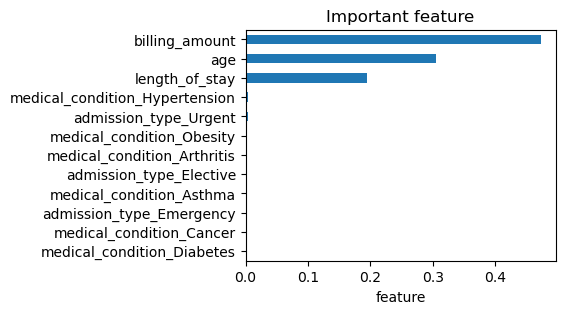

In [19]:
# feature importance
plt.figure(figsize=(4,3))
importance = pd.Series(model.feature_importances_, index=x.columns)
importance.sort_values().plot(kind='barh')
plt.title("Important feature")
plt.xlabel("feature")
plt.show()

##### Feature importance insights
The three most important features for predicting readmission are billing_amount, age, and length_of_stay.
Older patients are more likely to be readmitted because their immune system is weaker and recovery from disease is harder. Higher billing amount indicates a more serious or complex condition, which naturally carries a higher risk of complications and readmission. Longer length of stay suggests the patient's condition was severe — and severe conditions are more likely to require follow-up care.
Medical condition and admission type had almost zero importance — meaning the type of disease alone doesn't predict readmission as much as how long, how costly, and how old the patient is.

In [21]:
 ## sample prediction — create a fake patient and predict:
sample_patient = pd.DataFrame({
    'age': [65],
    'length_of_stay': [20],
    'billing_amount': [45000],
    'medical_condition_Arthritis': [0],
    'medical_condition_Asthma': [0],
    'medical_condition_Cancer': [1],
    'medical_condition_Diabetes': [0],
    'medical_condition_Hypertension': [0],
    'medical_condition_Obesity': [0],
    'admission_type_Elective': [0],
    'admission_type_Emergency': [1],
    'admission_type_Urgent': [0]
})

prediction = model.predict(sample_patient)
probability = model.predict_proba(sample_patient)

print("Readmission Risk:", "HIGH" if prediction[0] == 1 else "LOW")
print("Probability:", round(probability[0][1] * 100, 2), "%")

Readmission Risk: LOW
Probability: 13.0 %


#### **Important:**
Even for a high-risk patient profile — elderly, Cancer, Emergency admission, high billing — the model still predicts LOW risk due to ***class imbalance***. This demonstrates why ***SMOTE*** or class balancing is critical before deploying any healthcare ML model.

In [23]:
# Saving the Trained model
import pickle
with open('/Users/bulbulgupta/Documents/hospital_intelligence/scripts/model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("model saved")

model saved


1. SMOTE stands for "Synthetic Minority Over-sampling Technique"
2. Current split is 85% not readmitted, 15% readmitted
3. SMOTE will create synthetic readmitted patient examples to balance it

##### **NOTE:**
SMOTE creates synthetic (fake but realistic) examples of the minority class (readmitted patients) by slightly varying existing examples, balancing the dataset from 85/15 to approximately 50/50.

In [28]:
# installing the imbalanced_learn class
!pip install imbalanced-learn

In [29]:
# import SMOTE
from imblearn.over_sampling import SMOTE

In [32]:
# apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)
print("Before SMOTE :", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_balanced.value_counts().to_dict())

Before SMOTE : {0: 37581, 1: 6732}
After SMOTE : {0: 37581, 1: 37581}


In [33]:
# Recreating the Model after balancing the data
model_balanced = RandomForestClassifier(n_estimators=100, random_state=42)
model_balanced.fit(x_train_balances, y_train_balanced)
y_pred_balanced = model_balanced.predict(x_test)

In [34]:
# print the accuracy and classification report
print(accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

0.8266088997201914
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      9446
           1       0.17      0.04      0.07      1633

    accuracy                           0.83     11079
   macro avg       0.51      0.50      0.49     11079
weighted avg       0.75      0.83      0.78     11079



###### Before SMOTE:

- Accuracy: 83.6%
- Recall (readmitted): 3%

###### After SMOTE:

- Accuracy: 82.6%
- Recall (readmitted): 4%